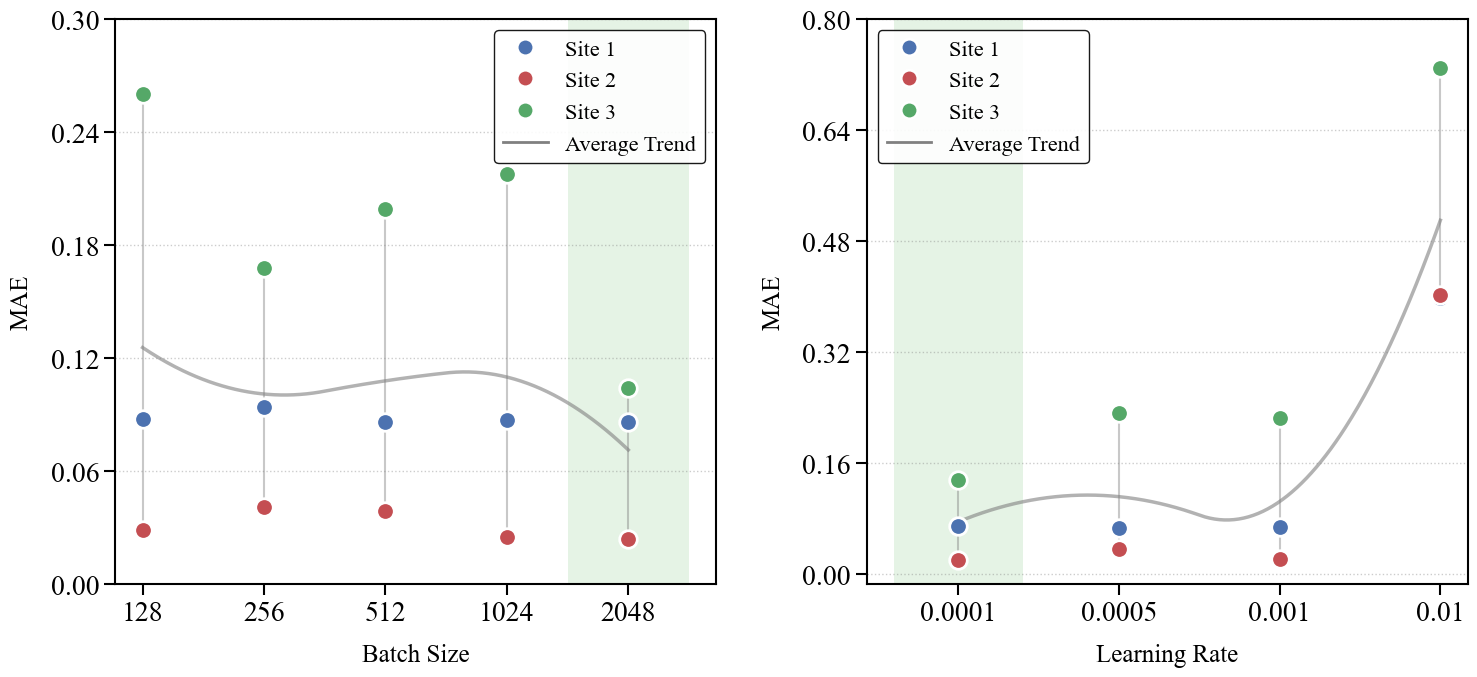

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from scipy.interpolate import make_interp_spline 

batch_size_data = {
    'Batch Size': [128, 256, 512, 1024, 2048],
    'Site 1': [0.088, 0.094, 0.086, 0.087, 0.086],
    'Site 2': [0.029, 0.041, 0.039, 0.025, 0.024],
    'Site 3': [0.260, 0.168, 0.199, 0.218, 0.104]
}

lr_data = {
    'Learning Rate': [0.0001, 0.0005, 0.001, 0.01],
    'Site 1': [0.069, 0.066, 0.067, 0.397],
    'Site 2': [0.020, 0.035, 0.021, 0.402],
    'Site 3': [0.135, 0.232, 0.224, 0.730]
}

colors = {"Site 1": "#4c72b0", "Site 2": "#c44e52", "Site 3": "#55a868"}
sites = ["Site 1", "Site 2", "Site 3"]


plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 1.5
fig, axes = plt.subplots(1, 2, figsize=(15, 7))


def plot_with_connections(ax, data_dict, x_key, title_x, title_y, highlight_idx):

    x_labels = [str(x) for x in data_dict[x_key]]
    x_positions = np.arange(len(x_labels))

    ax.axvspan(highlight_idx[0], highlight_idx[1], facecolor='#2ca02c', alpha=0.12, zorder=0, edgecolor='none')
    
    ax.grid(axis='y', linestyle=':', linewidth=1, color='gray', alpha=0.4, zorder=0.5)


    means = [] 
    for i in x_positions:
        current_y_values = [data_dict[site][i] for site in sites]
        y_min = min(current_y_values)
        y_max = max(current_y_values)
        y_mean = np.mean(current_y_values)
        means.append(y_mean)
        
        ax.plot([i, i], [y_min, y_max], color='#777777', linewidth=1.5, alpha=0.4, zorder=1)

    x_smooth = np.linspace(x_positions.min(), x_positions.max(), 300)
    
    try:
        spl = make_interp_spline(x_positions, means, k=2) 
        y_smooth = spl(x_smooth)
        

        ax.plot(x_smooth, y_smooth, color='gray', linestyle='-', linewidth=2.5, alpha=0.6, zorder=2, label='Average Trend')
    except:
 
        ax.plot(x_positions, means, color='gray', linestyle='-', linewidth=2.5, alpha=0.6, zorder=2, label='Average Trend')

    for i, site in enumerate(sites):
        y_vals = data_dict[site]
        ax.scatter(x_positions, y_vals, color=colors[site], s=160, 
                   edgecolor='white', linewidth=2, zorder=3, label=site, alpha=1.0)


    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=16, fontweight='normal') 
    
    ax.set_yticks(np.linspace(0, ax.get_yticks()[-1], 6))
    ax.tick_params(axis='both', which='major', labelsize=20, width=1.5, length=8)

    ax.set_xlabel(title_x, fontsize=18, labelpad=12)
    ax.set_ylabel(title_y, fontsize=18, labelpad=12)
    

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

    legend_handles = [
        mlines.Line2D([], [], color=c, marker='o', linestyle='None', 
                      markersize=12, markeredgecolor='white', markeredgewidth=2, label=s) 
        for s, c in colors.items()
    ]

    legend_handles.append(mlines.Line2D([], [], color='gray', linestyle='-', linewidth=2, label='Average Trend'))
    
    ax.legend(handles=legend_handles, loc='upper left' if 'Rate' in title_x else 'upper right', 
              frameon=True, framealpha=0.9, edgecolor='black', fontsize=16)



plot_with_connections(axes[0], batch_size_data, 'Batch Size', 
                      "Batch Size", "MAE", (3.5, 4.5))

plot_with_connections(axes[1], lr_data, 'Learning Rate', 
                      "Learning Rate", "MAE", (-0.4, 0.4))

plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.savefig('./New_Learning_Rate_and_Batch_Size_Analysis.pdf', dpi=600, format='pdf', bbox_inches='tight')
plt.show()